# Health Risk - Data Understanding
Integrantes:
- Diego Fabrizio Mucha Alvarez
- Ivan Ruben Cunyas Ramos
- Mauricio Andrés Canchis Fernández
- Juan Jose Rodriguez Velásquez
- María Laura Aragon Flores

En este notebook se realizará la fase 2 de CRISP-DM que es el data understanding. Para esto vamos a realizar una parte del EDA para poder analizar y ir descubriendo que contiene y como funciona nuestra data.

Importamos las librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 0. Carga y Configuración Inicial del Dataset

### 0.1. Cargar Dataset

In [2]:
df_raw = pd.read_csv("../data/raw/SEER_data.csv")

/tmp/ipykernel_202150/1286513731.py:1: DtypeWarning: Columns (0: Regional nodes examined (1988+), 1: Regional nodes positive (1988+)) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../data/raw/SEER_data.csv")


Original columns

In [3]:
df_raw.columns

Index(['Age recode with <1 year olds and 90+',
       'Race recode (White, Black, Other)', 'Sex', 'Year of diagnosis',
       'Primary Site - labeled', 'Histologic Type ICD-O-3',
       'Tumor Size Summary (2016+)', 'Tumor Size Over Time Recode (1988+)',
       'Diagnostic Confirmation',
       'Combined Summary Stage with Expanded Regional Codes (2004+)',
       'Summary stage 2000 (1998-2017)', 'Site recode ICD-O-3/WHO 2008',
       'Behavior recode for analysis', 'SEER historic stage A (1973-2015)',
       'Grade Recode (thru 2017)', 'Regional nodes examined (1988+)',
       'Regional nodes positive (1988+)', 'CS lymph nodes (2004-2015)',
       'SEER Combined Mets at DX-bone (2010+)',
       'SEER Combined Mets at DX-brain (2010+)',
       'SEER Combined Mets at DX-liver (2010+)',
       'SEER Combined Mets at DX-lung (2010+)', 'CS mets at dx (2004-2015)',
       'CS extension (2004-2015)', 'RX Summ--Surg Prim Site (1998-2022)',
       'Radiation recode', 'Chemotherapy recode (yes,

### 0.2. Eliminar columnas repetidas
Eliminar columnas que tienen significados parecidos para un mejor análisis del dataset

- Tumor Size Summary (2016+)
- Behavior recode for analysis
- Tumor Size Over Time Recode (1988+)
- Race recode (White, Black, Other)
- Summary stage 2000 (1998-2017)
- Primary Site - labeled
- SEER historic stage A (1973-2015)
- CS lymph nodes (2004-2015)
- CS mets at dx (2004-2015)
- Survival Days
- CS extension (2004-2015)
- Diagnostic Confirmation
- Laterality
- Regional nodes positive (1988+)
- Regional nodes examined (1998+)
- SEER cause-specific death classification
- Vital status recode (study cutoff used)
- Radiation recode

In [4]:
columns_to_drop = [
    "Tumor Size Summary (2016+)",
    "Tumor Size Over Time Recode (1988+)",
    "Race recode (White, Black, Other)",
    "Summary stage 2000 (1998-2017)",
    "Primary Site - labeled",
    "SEER historic stage A (1973-2015)",
    "CS lymph nodes (2004-2015)",
    "CS mets at dx (2004-2015)",
    "Survival Days",
    "Diagnostic Confirmation",
    "Laterality",
    "Regional nodes examined (1988+)",
    "Behavior recode for analysis",
    "Reason no cancer-directed surgery",
    "SEER cause-specific death classification",
    "Vital status recode (study cutoff used)",
    "Radiation recode",
    "Regional nodes positive (1988+)",
    "CS extension (2004-2015)"
]

df_raw = df_raw.drop(columns=columns_to_drop)

Columnas restantes

In [5]:
df_raw.columns

Index(['Age recode with <1 year olds and 90+', 'Sex', 'Year of diagnosis',
       'Histologic Type ICD-O-3',
       'Combined Summary Stage with Expanded Regional Codes (2004+)',
       'Site recode ICD-O-3/WHO 2008', 'Grade Recode (thru 2017)',
       'SEER Combined Mets at DX-bone (2010+)',
       'SEER Combined Mets at DX-brain (2010+)',
       'SEER Combined Mets at DX-liver (2010+)',
       'SEER Combined Mets at DX-lung (2010+)',
       'RX Summ--Surg Prim Site (1998-2022)',
       'Chemotherapy recode (yes, no/unk)', 'Survival months'],
      dtype='str')

### 0.3. Renombrar columnas
Renombramiento de columnas para un mejor análisis del dataset

- Age recode with <1 year olds and 90+ **->** age_group
- Sex **->** sex
- Year of diagnosis **->** diagnosis_year
- Histologic Type ICD-O-3 **->** histologic_type
- Combined Summary Stage with Expanded Regional Codes (2004+) **->** cancer_stage
- Site recode ICD-O-3/WHO 2008 **->** cancer_site
- Grade Recode (thru 2017) **->** tumor_grade
- Regional nodes positive (1988+) **->** regional_nodes_positive
- SEER Combined Mets at DX-bone (2010+) **->** bone_metastasis_at_dx
- SEER Combined Mets at DX-brain (2010+) **->** brain_metastasis_at_dx
- SEER Combined Mets at DX-liver (2010+) **->** liver_metastasis_at_dx
- SEER Combined Mets at DX-lung (2010+) **->** lung_metastasis_at_dx
- RX Summ--Surg Prim Site (1998-2022) **->** primary_site_surgery
- Chemotherapy recode (yes, no/unk) **->** received_chemotherapy
- Survival months **->** survival_months

In [6]:
new_column_names = [
    'age_group',
    'sex',
    'diagnosis_year',
    'histologic_type',
    'cancer_stage',
    'cancer_site',
    'tumor_grade',
    'bone_metastasis_at_dx',
    'brain_metastasis_at_dx',
    'liver_metastasis_at_dx',
    'lung_metastasis_at_dx',
    'primary_site_surgery',
    'received_chemotherapy',
    'survival_months',
]

df_raw.columns = new_column_names

Nuevas columnas

In [7]:
df_raw.columns

Index(['age_group', 'sex', 'diagnosis_year', 'histologic_type', 'cancer_stage',
       'cancer_site', 'tumor_grade', 'bone_metastasis_at_dx',
       'brain_metastasis_at_dx', 'liver_metastasis_at_dx',
       'lung_metastasis_at_dx', 'primary_site_surgery',
       'received_chemotherapy', 'survival_months'],
      dtype='str')

### 0.3. Fecha de las variables

Se puede ver de las fechas de las variables, que muchas de estas no tienen cobertura antes de cierto años, y luego de hacer un análisis de estas, hemos decidido recortar el dataset para solo diagnosticos que sean del año 2010 a mas

In [8]:
df_raw = df_raw[df_raw["diagnosis_year"] >= 2010]

## 1. Análisis Inicial de los Datos

### 1.1. Estructura del Dataset

Creamos del dataframe testing que reemplace a raw

In [9]:
df_testing = df_raw

Vista inicial de las primeras columnas del dataset

In [10]:
df_testing.head()

,age_group,sex,diagnosis_year,histologic_type,cancer_stage,cancer_site,tumor_grade,bone_metastasis_at_dx,brain_metastasis_at_dx,liver_metastasis_at_dx,lung_metastasis_at_dx,primary_site_surgery,received_chemotherapy,survival_months
62,85-89 years,Male,2012,9732,Distant site(s)/node(s) involved,Myeloma,B-cell; pre-B; B-precursor,NaN,NaN,NaN,NaN,98,No/Unknown,0053
64,70-74 years,Female,2010,8500,Localized only,Breast,Poorly differentiated; Grade III,No,No,No,No,80,No/Unknown,0012
65,70-74 years,Female,2018,8500,Localized only,Breast,Blank(s),No,No,No,No,22,Yes,0070
81,60-64 years,Female,2023,8500,Localized only,Breast,Blank(s),No,No,No,No,Blank(s),No/Unknown,0011
92,55-59 years,Female,2016,8441,Regional by direct extension only,Ovary,Moderately differentiated; Grade II,No,No,No,No,56,Yes,0095


Cantidad de samples y features

In [11]:
samples = df_testing.shape[0]
features = df_testing.shape[1]
print(f"Samples: {df_testing.shape[0]}")
print(f"Features: {df_testing.shape[1]}")

Samples: 1904411
Features: 14


Features del dataset

In [12]:
print(df_testing.columns)

Index(['age_group', 'sex', 'diagnosis_year', 'histologic_type', 'cancer_stage',
       'cancer_site', 'tumor_grade', 'bone_metastasis_at_dx',
       'brain_metastasis_at_dx', 'liver_metastasis_at_dx',
       'lung_metastasis_at_dx', 'primary_site_surgery',
       'received_chemotherapy', 'survival_months'],
      dtype='str')


Tipo de dato de cada feature

In [13]:
df_testing.dtypes

age_group                   str
sex                         str
diagnosis_year            int64
histologic_type           int64
cancer_stage                str
cancer_site                 str
tumor_grade                 str
bone_metastasis_at_dx       str
brain_metastasis_at_dx      str
liver_metastasis_at_dx      str
lung_metastasis_at_dx       str
primary_site_surgery        str
received_chemotherapy       str
survival_months             str
dtype: object

### 1.2. Identificación de filas repetidas y valores nulos

Revisar si hay valores nulos en porcentaje

In [14]:
df_testing.isna().sum().sort_values(ascending=False) / samples * 100

lung_metastasis_at_dx     9.424594
brain_metastasis_at_dx    9.413462
liver_metastasis_at_dx    9.412779
bone_metastasis_at_dx     9.411624
age_group                 0.000000
sex                       0.000000
cancer_site               0.000000
cancer_stage              0.000000
histologic_type           0.000000
diagnosis_year            0.000000
tumor_grade               0.000000
primary_site_surgery      0.000000
received_chemotherapy     0.000000
survival_months           0.000000
dtype: float64

Las columnas que son nulas son aproximadamente un 12% del dataset. Se sugiere eliminar las filas que contienen valores nulos

In [15]:
print(f"Cantidad de samples antes de la eliminación de nulos: {samples}")
df_testing = df_testing.dropna()
samples = df_testing.shape[0]
print(f"Cantidad de samples despues de la eliminación de nulos: {samples}")

Cantidad de samples antes de la eliminación de nulos: 1904411
Cantidad de samples despues de la eliminación de nulos: 1724798


Revisar filas repetidas en porcentaje

In [16]:
print(f"Porcentaje de filas duplicadas: {df_testing.duplicated().sum() / samples * 100} %")

Porcentaje de filas duplicadas: 29.067345857311988 %


Eliminar las filas repetidas

In [17]:
print(f"Cantidad de samples antes de la eliminación de nulos: {samples}")
df_testing = df_testing.drop_duplicates()
samples = df_testing.shape[0]
print(f"Cantidad de samples despues de la eliminación de nulos: {samples}")

Cantidad de samples antes de la eliminación de nulos: 1724798
Cantidad de samples despues de la eliminación de nulos: 1223445


### 1.3. Sugerencia de cambios para algunas variables

Sugerencia de encoding de la variable age_group. Esta variable tiene las edades en los siguientes intervalos:


In [18]:
dic_encoding = {"00 years":0, "01-04 years":1, "05-09 years": 2, "10-14 years": 3, "15-19 years": 4, "20-24 years": 5, "25-29 years": 6, "30-34 years": 7, "35-39 years": 8, "40-44 years": 9, "45-49 years": 10, "50-54 years": 11, "55-59 years": 12, "60-64 years": 13, "65-69 years": 14}
df_testing["age_group"] = df_testing["age_group"].map(dic_encoding)

Sugerencia de cambiar tipo de dato a int a la variable survival_months, primero vamos a eliminar todas los samples que tienen a esa variable con la clase unknown.

In [19]:
df_testing = df_testing[df_testing["survival_months"] != "Unknown"]
df_testing["survival_months"] = df_testing["survival_months"].astype(int)

Sugerencia de categorizar los valores de la columna primary_site_surgery
- 00 **→** No surgery
- 01-29 **→** Local/Minor surgery
- 30-59 **→** Partial/Organ surgery
- 60-89 **→** Extensive/Radical surgery
- 90 **→** Surgery, NOS
- 98 **→** Not applicable
- 99 **→** Unkown

In [20]:
df_testing.loc[df_testing["primary_site_surgery"] == "Blank(s)", "primary_site_surgery"] = "Unknown"

def map_surgery(code):
    if str(code) == "Unknown" or str(code) == "Blank(s)":
        return "Unknown"
    code = int(code)
    if code == 0:
        return "no_surgery"
    elif 1 <= code <= 29:
        return "minor_surgery"
    elif 30 <= code <= 59:
        return "partial_surgery"
    elif 60 <= code <= 89:
        return "radical_surgery"
    elif code == 90:
        return "surgery_nos"
    elif code == 98:
        return "not_applicable"
    elif code == 99:
        return "Unknown"
    else:
        print(code)
        return "other"  # safety fallback

df_testing["primary_site_surgery"] = df_testing["primary_site_surgery"].apply(map_surgery)

Sugerencia de agrupar los tipos de cancer en categorias de la columna cancer_site

In [21]:
site_group_map = {
    # Cancer de cabeza y Cuello
    "Lip": "Head and Neck",
    "Tongue": "Head and Neck",
    "Salivary Gland": "Head and Neck",
    "Floor of Mouth": "Head and Neck",
    "Gum and Other Mouth": "Head and Neck",
    "Nasopharynx": "Head and Neck",
    "Tonsil": "Head and Neck",
    "Oropharynx": "Head and Neck",
    "Hypopharynx": "Head and Neck",
    "Other Oral Cavity and Pharynx": "Head and Neck",

    # CAncer de sistema digestivo
    "Esophagus": "Digestive",
    "Stomach": "Digestive",
    "Small Intestine": "Digestive",
    "Cecum": "Digestive",
    "Appendix": "Digestive",
    "Ascending Colon": "Digestive",
    "Hepatic Flexure": "Digestive",
    "Transverse Colon": "Digestive",
    "Splenic Flexure": "Digestive",
    "Descending Colon": "Digestive",
    "Sigmoid Colon": "Digestive",
    "Large Intestine, NOS": "Digestive",
    "Rectosigmoid Junction": "Digestive",
    "Rectum": "Digestive",
    "Anus, Anal Canal and Anorectum": "Digestive",
    "Liver": "Digestive",
    "Intrahepatic Bile Duct": "Digestive",
    "Gallbladder": "Digestive",
    "Other Biliary": "Digestive",
    "Pancreas": "Digestive",
    "Retroperitoneum": "Digestive",
    "Peritoneum, Omentum and Mesentery": "Digestive",
    "Other Digestive Organs": "Digestive",

    # Cancer respiratorio
    "Nose, Nasal Cavity and Middle Ear": "Respiratory",
    "Larynx": "Respiratory",
    "Lung and Bronchus": "Respiratory",
    "Pleura": "Respiratory",
    "Trachea, Mediastinum and Other Respiratory Organs": "Respiratory",

    # Otros tumores solidos
    "Bones and Joints": "Bone and Soft Tissue",
    "Soft Tissue including Heart": "Bone and Soft Tissue",
    "Melanoma of the Skin": "Skin",
    "Other Non-Epithelial Skin": "Skin",
    "Breast": "Breast",

    # Genitales femeninos
    "Cervix Uteri": "Female Genital",
    "Corpus Uteri": "Female Genital",
    "Uterus, NOS": "Female Genital",
    "Ovary": "Female Genital",
    "Vagina": "Female Genital",
    "Vulva": "Female Genital",
    "Other Female Genital Organs": "Female Genital",

    # Genitales masculinos
    "Prostate": "Male Genital",
    "Testis": "Male Genital",
    "Penis": "Male Genital",
    "Other Male Genital Organs": "Male Genital",

    # Urinarios
    "Urinary Bladder": "Urinary",
    "Kidney and Renal Pelvis": "Urinary",
    "Ureter": "Urinary",
    "Other Urinary Organs": "Urinary",

    # Otros sistemas mayores
    "Eye and Orbit": "Eye",
    "Brain and Other Nervous System": "Brain/CNS",
    "Thyroid": "Endocrine",
    "Other Endocrine including Thymus": "Endocrine",

    # Hematologicos o raros
    "Hodgkin - Nodal": "Hematologic",
    "Hodgkin - Extranodal": "Hematologic",
    "NHL - Nodal": "Hematologic",
    "NHL - Extranodal": "Hematologic",
    "Myeloma": "Hematologic",
    "Acute Lymphocytic Leukemia": "Hematologic",
    "Chronic Lymphocytic Leukemia": "Hematologic",
    "Other Lymphocytic Leukemia": "Hematologic",
    "Acute Myeloid Leukemia": "Hematologic",
    "Acute Monocytic Leukemia": "Hematologic",
    "Chronic Myeloid Leukemia": "Hematologic",
    "Other Myeloid/Monocytic Leukemia": "Hematologic",
    "Other Acute Leukemia": "Hematologic",
    "Aleukemic, subleukemic and NOS": "Hematologic",
    "Mesothelioma": "Hematologic",
    "Kaposi Sarcoma": "Hematologic",
    "Miscellaneous": "Hematologic",

    # No se sabe o no validos
    "Invalid": "Unknown/Invalid"
}

df_testing["cancer_site"] = df_testing["cancer_site"].map(site_group_map).fillna("Other/Unmapped")

Sugerencia de convertir las 4 columnas de metastasis a una sola para verficar si hay metastasis o no

In [22]:
met_cols = [
    "bone_metastasis_at_dx",
    "brain_metastasis_at_dx",
    "liver_metastasis_at_dx",
    "lung_metastasis_at_dx"
]
df_testing["metastasis_count"] = df_testing[met_cols].eq("Yes").sum(axis=1)
df_testing["metastasis_count"].value_counts()
df_testing = df_testing.drop(columns=["bone_metastasis_at_dx","brain_metastasis_at_dx", "liver_metastasis_at_dx", "lung_metastasis_at_dx"])

Sugerencia de convertir la variable de histologic_type a una categorica ya que los numeros reaclmente son codigos para tipos de histologia. Quedarse con los 15 primeros y el resto ponerlos diferentes

In [23]:
top_histologies = df_testing["histologic_type"].value_counts().head(15).index

df_testing["histologic_type_grouped"] = df_testing["histologic_type"].where(df_testing["histologic_type"].isin(top_histologies), "Other")

Sugerencia de convertir la variable recieved_chemeotherapy a booleano

In [24]:
df_testing["received_chemotherapy"] = df_testing["received_chemotherapy"].map({"Yes": 1, "No/Unknown": 0}).astype(int)

Sugerencia de categorizar mas la variable cancer_stage, y quitar los valores unknown que contiene esta por lo importante que es

In [25]:
stage_map = {
    "In situ": "in_situ",
    "Localized only": "localized",
    "Regional by direct extension only": "regional",
    "Regional lymph nodes involved only": "regional",
    "Regional by both direct extension and lymph node involvement": "regional",
    "Distant site(s)/node(s) involved": "distant",
    "Unknown/unstaged/unspecified/DCO": "unknown"
}
df_testing["cancer_stage"] = df_testing["cancer_stage"].map(stage_map)

ordinal_stage_map = {
    "in_situ": 0,
    "localized": 1,
    "regional": 2,
    "distant": 3
}

df_testing["cancer_stage"] = df_testing["cancer_stage"].map(ordinal_stage_map)
df_testing = df_testing.dropna()

Sugerencia para convertir la variable sex en booleana

In [26]:
df_testing["sex"] = df_testing["sex"].map({"Male": 1, "Female": 0}).astype(int)

Sugerencia para convertir la variable survival_months a categorica ordinal y encoded, pra que asi nuestro target tenga encoding

In [27]:
df_testing["survival_risk"] = pd.qcut(df_testing["survival_months"], q=5, labels=[0, 1, 2, 3, 4])
df_testing["survival_risk"] = df_testing["survival_risk"].astype(int)
df_testing = df_testing.drop(columns=["survival_months"])

## 2. Análisis Estadístico de los Datos

### 2.1. Datos estadisticos basicos por cada variable

In [28]:
print("Para columnas numericas")
df_testing_numeric = df_testing.select_dtypes("number")

for column in df_testing_numeric:
    print(f"Column: {df_testing_numeric.describe()}")


Para columnas numericas
Column:            age_group            sex  diagnosis_year  histologic_type  \
count  679843.000000  679843.000000   679843.000000    679843.000000   
mean       11.547459       0.451735     2016.259782      8409.954981   
std         2.438987       0.497665        3.901006       395.670367   
min         0.000000       0.000000     2010.000000      8000.000000   
25%        10.000000       0.000000     2013.000000      8140.000000   
50%        12.000000       0.000000     2016.000000      8260.000000   
75%        13.000000       1.000000     2020.000000      8500.000000   
max        14.000000       1.000000     2023.000000      9971.000000   

        cancer_stage  received_chemotherapy  metastasis_count  survival_risk  
count  679843.000000          679843.000000     679843.000000  679843.000000  
mean        1.736411               0.427446          0.204384       1.986676  
std         0.831049               0.494708          0.559921       1.417832  
min

In [29]:
print("Para variables categóricas")
df_testing_categorical = df_testing.drop(columns=df_testing_numeric.columns)

for column in df_testing_categorical:
    print(f"Column: {column}")
    print(f"{df_testing_categorical[column].value_counts()}")

Para variables categóricas
Column: cancer_site
cancer_site
Digestive               158515
Breast                  116748
Respiratory              84615
Female Genital           55601
Urinary                  55592
Skin                     46548
Male Genital             39811
Endocrine                34644
Head and Neck            30455
Hematologic              27238
Other/Unmapped           16419
Bone and Soft Tissue     11497
Eye                       2160
Name: count, dtype: int64
Column: tumor_grade
tumor_grade
Blank(s)                                  267904
Unknown                                   144464
Moderately differentiated; Grade II       108596
Poorly differentiated; Grade III           81705
Well differentiated; Grade I               49551
Undifferentiated; anaplastic; Grade IV     20683
B-cell; pre-B; B-precursor                  5568
T-cell                                      1341
NK cell; natural killer cell (1995+)          28
Null cell; non T-non B                 

### 2.2. Gráficos estadísticos para variables numéricas

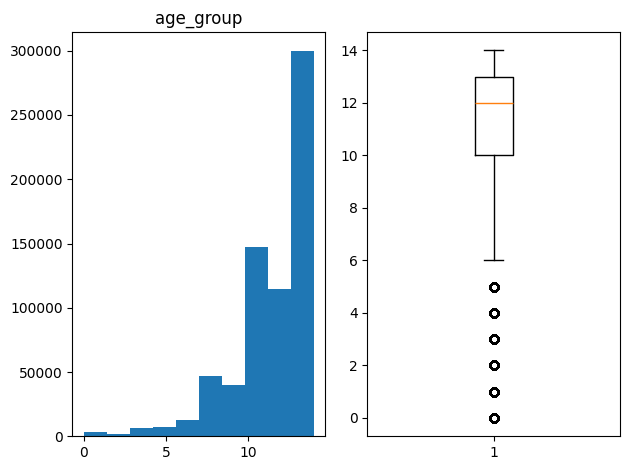

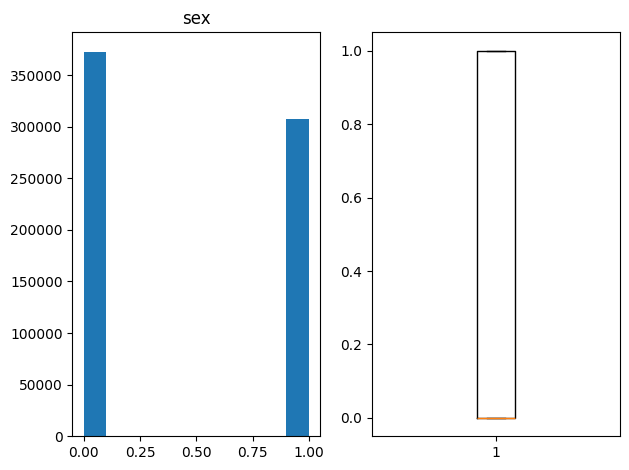

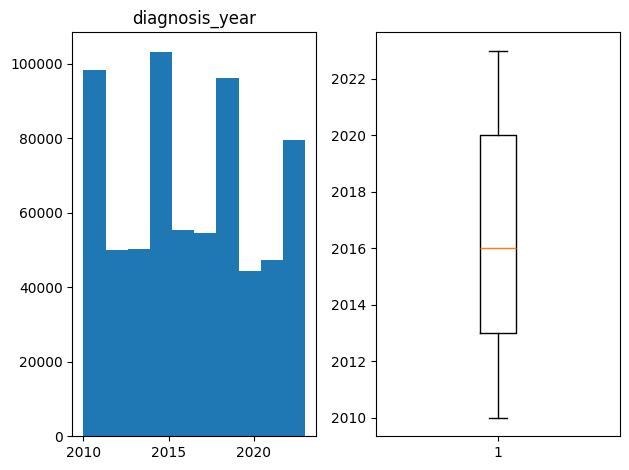

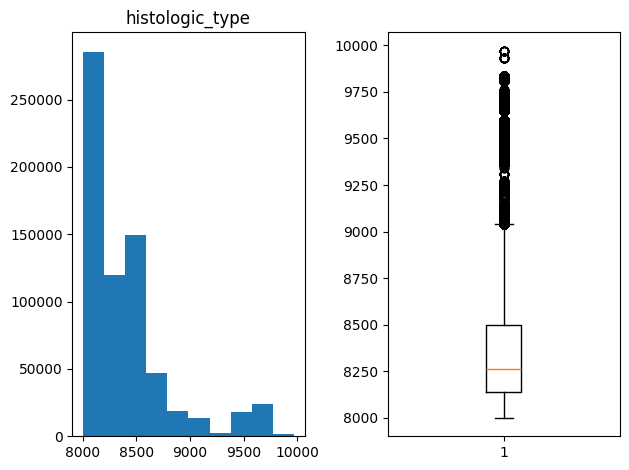

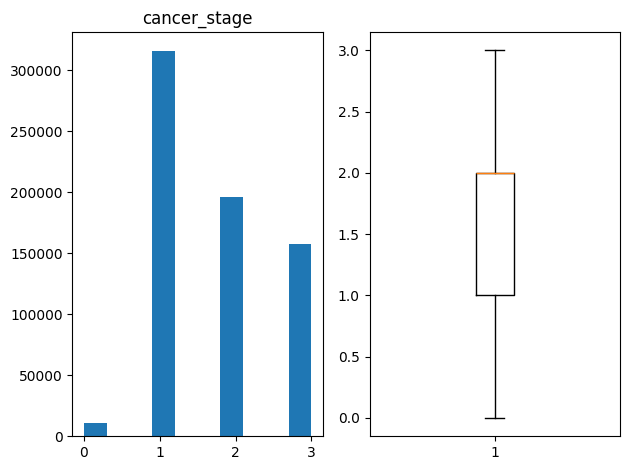

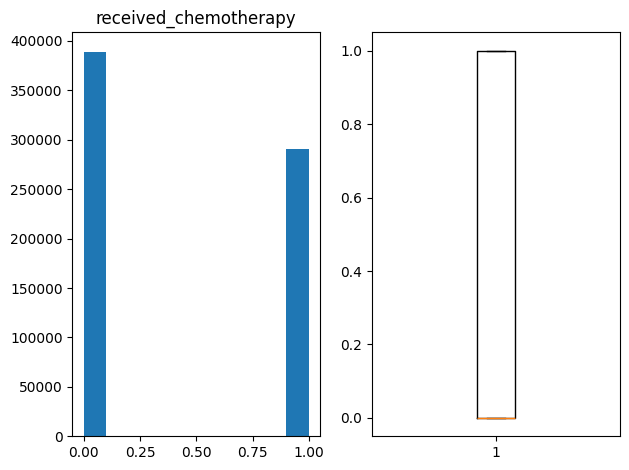

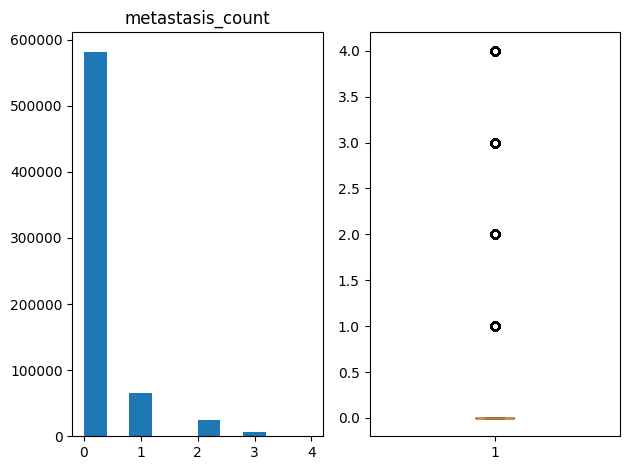

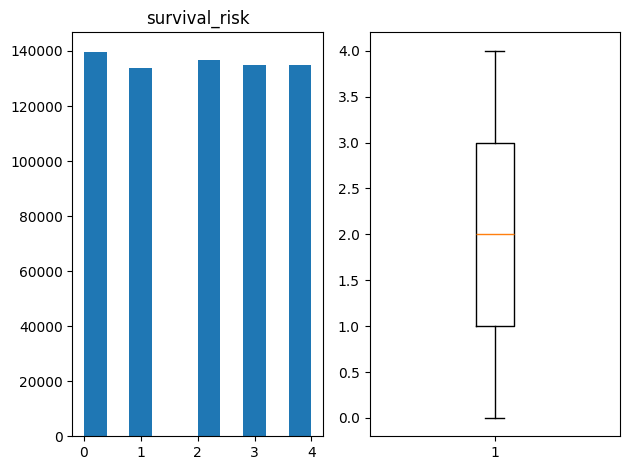

In [30]:
for column in df_testing_numeric:
    plt.subplot(1, 2, 1)
    plt.title(column)
    plt.hist(df_testing_numeric[column])
    plt.subplot(1, 2, 2)
    plt.boxplot(df_testing_numeric[column])
    plt.tight_layout()
    plt.show()

### 2.3. Gráficos estadísticos para variables categóricas

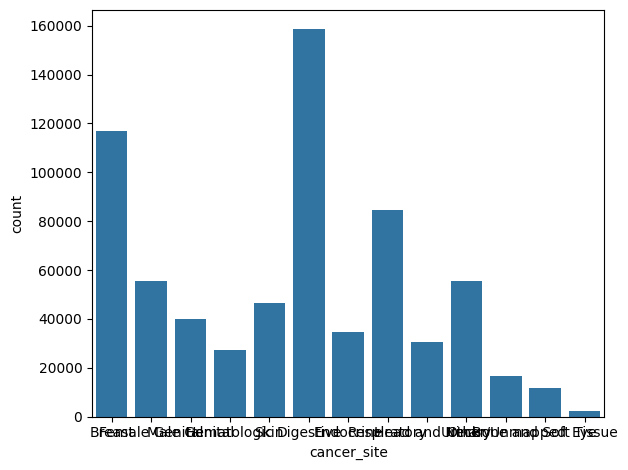

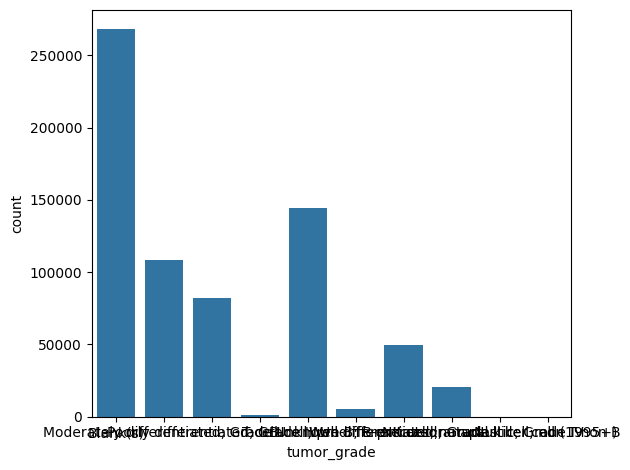

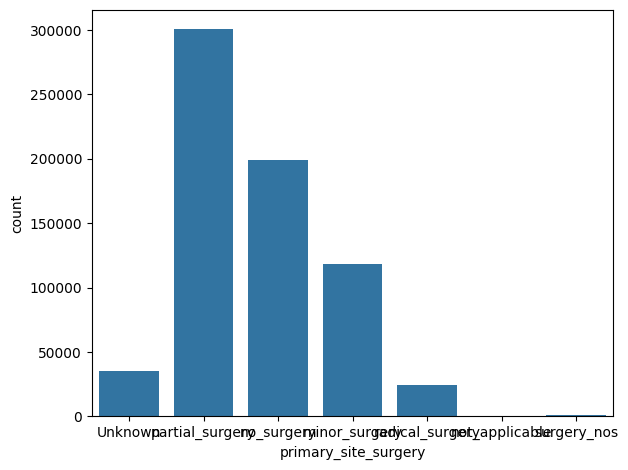

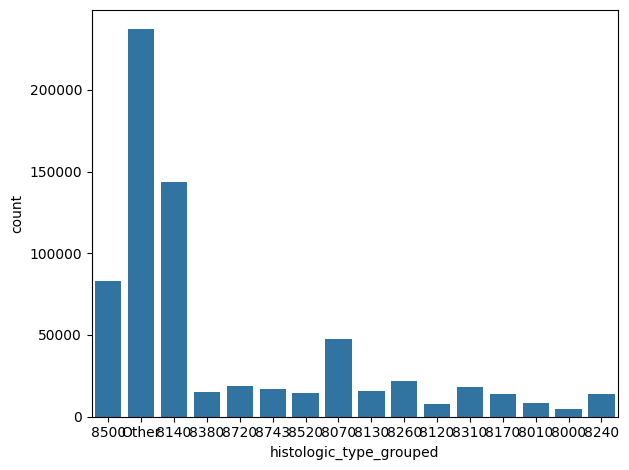

In [31]:
for column in df_testing_categorical:
    sns.countplot(x=column, data=df_testing_categorical)
    plt.tight_layout()
    plt.show()

### 2.4. Sugerencias para hacer encoding a las variables categoricas

Para las variables categoricas que quedan, se recomienda hacer un one hot encoding, ya que el resto de variables categoricas ya anteriomrnete fueron convertidas a numericas y ordinales

In [32]:
df_testing_num = df_testing
df_testing = pd.get_dummies(df_testing,columns=["histologic_type_grouped", "primary_site_surgery", "tumor_grade", "cancer_site"], drop_first=True)


## 3. Análisis Bivariado

### 3.1. Revisamos la correlación entre las variables

In [33]:
df_testing.corr()

,age_group,sex,diagnosis_year,histologic_type,cancer_stage,received_chemotherapy,metastasis_count,survival_risk,histologic_type_grouped_8010,histologic_type_grouped_8070,...,cancer_site_Endocrine,cancer_site_Eye,cancer_site_Female Genital,cancer_site_Head and Neck,cancer_site_Hematologic,cancer_site_Male Genital,cancer_site_Other/Unmapped,cancer_site_Respiratory,cancer_site_Skin,cancer_site_Urinary
age_group,1.000000,0.078846,-0.019994,-0.282866,0.086225,-0.018473,0.074636,-0.121472,0.031060,0.069525,...,-0.160765,-0.036945,-0.018161,0.029400,-0.059729,0.008225,-0.142079,0.167435,-0.051868,0.058795
sex,0.078846,1.000000,0.010306,-0.068897,0.046735,-0.051222,0.063064,-0.110109,0.007981,0.075208,...,-0.060331,0.010937,-0.270902,0.117084,0.053482,0.274760,0.037754,0.062034,0.042373,0.141066
diagnosis_year,-0.019994,0.010306,1.000000,0.095552,0.069518,0.031259,0.037366,-0.513360,-0.000954,-0.016708,...,0.005324,0.002746,-0.002238,0.015684,0.145366,-0.045809,0.000409,-0.010341,-0.014350,-0.017045
histologic_type,-0.282866,-0.068897,0.095552,1.000000,-0.098249,0.020796,-0.135294,0.064754,-0.110895,-0.235456,...,-0.051331,0.050278,-0.025340,-0.160566,0.633743,-0.047819,0.398220,-0.253889,0.212790,-0.134660
cancer_stage,0.086225,0.046735,0.069518,-0.098249,1.000000,0.400878,0.553921,-0.396606,0.080628,0.059645,...,-0.082378,-0.039177,0.029709,0.029747,0.107858,-0.042767,-0.100941,0.244559,-0.170420,-0.188506
received_chemotherapy,-0.018473,-0.051222,0.031259,0.020796,0.400878,1.000000,0.159525,-0.141712,-0.005428,0.062506,...,-0.179760,-0.031345,0.057978,0.020729,0.082967,-0.137727,0.057092,0.076459,-0.221900,-0.105672
metastasis_count,0.074636,0.063064,0.037366,-0.135294,0.553921,0.159525,1.000000,-0.332634,0.086093,-0.026808,...,-0.065650,-0.017434,-0.058227,-0.061727,-0.026577,-0.009597,-0.054875,0.247743,-0.071396,-0.029961
survival_risk,-0.121472,-0.110109,-0.513360,0.064754,-0.396606,-0.141712,-0.332634,1.000000,-0.068507,-0.045789,...,0.079012,0.013085,0.019685,0.006754,-0.052166,0.065148,-0.059139,-0.207197,0.100193,0.046265
histologic_type_grouped_8010,0.031060,0.007981,-0.000954,-0.110895,0.080628,-0.005428,0.086093,-0.068507,1.000000,-0.030065,...,-0.011415,-0.005470,0.014497,0.012320,-0.021998,0.006736,-0.017259,0.048616,-0.029743,-0.014169
histologic_type_grouped_8070,0.069525,0.075208,-0.016708,-0.235456,0.059645,0.062506,-0.026808,-0.045789,-0.030065,1.000000,...,-0.060826,0.000114,0.050813,0.399184,-0.052456,-0.055248,-0.042887,0.186560,-0.074297,-0.074767


<Axes: >

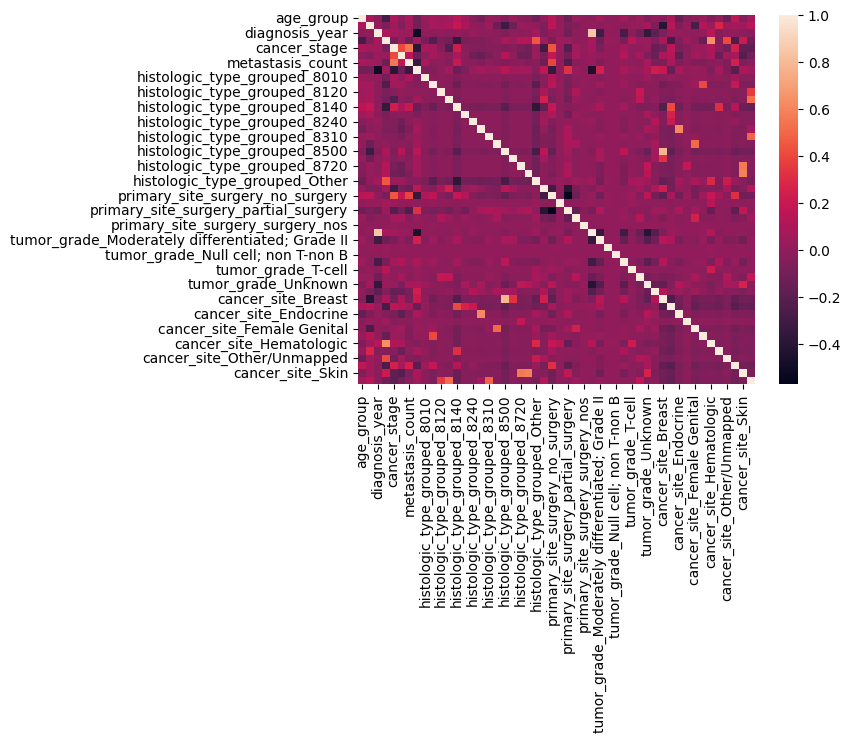

In [34]:
sns.heatmap(df_testing.corr())

## 4. Conclusiones

Se pueden dar las siguientes 3 fuertes conclusiones:
- El dataset tiene muchas variables que son altamente médicas, variables que ALDIMI no va a tener disponibles (mencionado directamente por ellos), ya que ALDIMI solo recibe información medica media del hospital de los pacientes.
- El dataset es completo y tiene data limpia luego de hacer bastante preprocesamiento, podemos ver que la data es buena y se puede hacer un trabajo efectivo con ella.
- La correlación con la varible objetivo es buena, no hay correlaciones excelentes pero si las variables tienen una correlación media, que será util para los modelos que construyamos a continuación.

